In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (8,5)
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv('../data/kidney_disease.csv')
df.head()

,id,age,blood pressure,specific gravity,albumin,sugar,red blood cells,pus cell,pus cell clumps,bacteria,...,packed cell volume,white blood cell count,red blood cell count,hypertension,diabetes mellitus,coronary artery disease,appetite,pedal edema,anemia,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       400 non-null    str    
 1   age                      376 non-null    float64
 2   blood pressure           376 non-null    float64
 3   specific gravity         341 non-null    float64
 4   albumin                  342 non-null    float64
 5   sugar                    340 non-null    float64
 6   red blood cells          243 non-null    str    
 7   pus cell                 324 non-null    str    
 8   pus cell clumps          381 non-null    str    
 9   bacteria                 381 non-null    str    
 10  blood glucose random     343 non-null    float64
 11  blood urea               367 non-null    float64
 12  serum creatinine         369 non-null    float64
 13  sodium                   304 non-null    float64
 14  potassium                303 non-null

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,serum creatinine,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count
count,376.000000,376.000000,341.000000,342.000000,340.000000,343.000000,367.000000,369.000000,304.000000,303.000000,338.000000,320.000000,286.000000,263.000000
mean,51.364362,76.303191,1.017595,0.985380,0.464706,148.180758,57.420163,3.096070,137.600329,4.633333,12.555030,38.937500,8416.783217,4.706464
std,16.960745,13.658837,0.005669,1.340686,1.113840,80.234940,50.992355,5.834599,10.504390,3.239284,2.936204,9.063128,2956.040168,1.005555
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,41.750000,70.000000,1.015000,0.000000,0.000000,99.500000,27.000000,0.900000,135.000000,3.800000,10.400000,32.000000,6500.000000,3.900000
50%,54.000000,80.000000,1.020000,0.000000,0.000000,121.000000,41.000000,1.200000,138.000000,4.400000,12.750000,40.500000,8000.000000,4.800000
75%,64.000000,80.000000,1.020000,2.000000,0.000000,162.500000,66.000000,2.800000,142.000000,4.900000,15.000000,45.250000,9800.000000,5.400000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,6.500000


In [4]:
df['classification'].value_counts()

classification
ckd       235
notckd    150
Name: count, dtype: int64

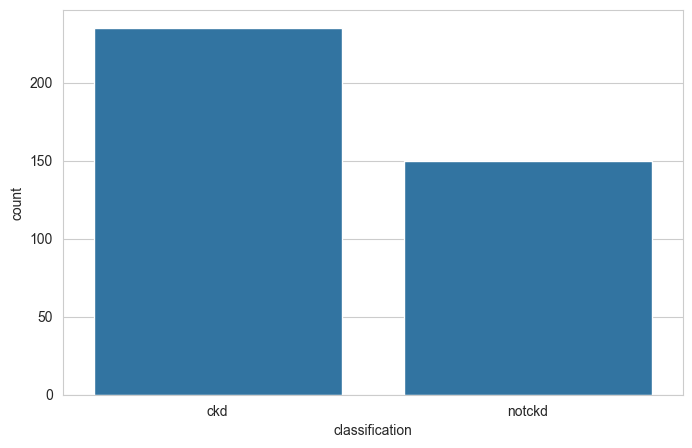

In [5]:
sns.countplot(x='classification', data=df)
plt.show()

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing

red blood cells            157
red blood cell count       137
white blood cell count     114
potassium                   97
sodium                      96
packed cell volume          80
pus cell                    76
hemoglobin                  62
sugar                       60
specific gravity            59
albumin                     58
blood glucose random        57
blood urea                  33
serum creatinine            31
age                         24
blood pressure              24
bacteria                    19
pus cell clumps             19
hypertension                17
diabetes mellitus           17
coronary artery disease     17
anemia                      16
appetite                    16
pedal edema                 16
classification              15
id                           0
dtype: int64

In [7]:
missing_percent = (missing / len(df)) * 100
missing_percent

red blood cells            39.25
red blood cell count       34.25
white blood cell count     28.50
potassium                  24.25
sodium                     24.00
packed cell volume         20.00
pus cell                   19.00
hemoglobin                 15.50
sugar                      15.00
specific gravity           14.75
albumin                    14.50
blood glucose random       14.25
blood urea                  8.25
serum creatinine            7.75
age                         6.00
blood pressure              6.00
bacteria                    4.75
pus cell clumps             4.75
hypertension                4.25
diabetes mellitus           4.25
coronary artery disease     4.25
anemia                      4.00
appetite                    4.00
pedal edema                 4.00
classification              3.75
id                          0.00
dtype: float64

In [8]:
#detect dirty values
for col in df.columns:
    print(col, df[col].unique()[:10])

id <StringArray>
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Length: 10, dtype: str
age [48.  7. 62. 51. 60. 68. 24. 52. 53. 50.]
blood pressure [ 80.  50.  70.  90.  nan 100.  60. 140. 180. 110.]
specific gravity [1.02  1.01  1.005 1.015   nan 1.025]
albumin  [ 1.  4.  2.  3.  0. nan  5.]
sugar [ 0.  3.  4.  1. nan  2.  5.]
red blood cells <StringArray>
[nan, 'normal', 'abnormal']
Length: 3, dtype: str
pus cell <StringArray>
['normal', 'abnormal', nan]
Length: 3, dtype: str
pus cell clumps <StringArray>
['notpresent', 'present', nan]
Length: 3, dtype: str
bacteria  <StringArray>
['notpresent', 'present', nan]
Length: 3, dtype: str
blood glucose random [121.  nan 423. 117. 106.  74. 100. 410. 138.  70.]
blood urea [ 36.  18.  53.  56.  26.  25.  54.  31.  60. 107.]
serum creatinine  [ 1.2  0.8  1.8  3.8  1.4  1.1 24.   1.9  7.2  4. ]
sodium [ nan 111. 142. 104. 114. 131. 138. 135. 130. 141.]
potassium [nan 2.5 3.2 4.  3.7 4.2 5.8 3.4 6.4 4.9]
hemoglobin [15.4 11.3  9.6 11.2 11.6

In [9]:
df.columns.tolist()

['id',
 'age',
 'blood pressure',
 'specific gravity',
 'albumin ',
 'sugar',
 'red blood cells',
 'pus cell',
 'pus cell clumps',
 'bacteria ',
 'blood glucose random',
 'blood urea',
 'serum creatinine ',
 'sodium',
 'potassium',
 'hemoglobin',
 'packed cell volume',
 'white blood cell count ',
 'red blood cell count',
 'hypertension',
 'diabetes mellitus',
 'coronary artery disease',
 'appetite',
 'pedal edema ',
 'anemia ',
 'classification']

In [10]:
df[['packed cell volume', 'white blood cell count ', 'red blood cell count']].head()

,packed cell volume,white blood cell count,red blood cell count
0,44.0,7800.0,5.2
1,38.0,6000.0,NaN
2,31.0,7500.0,NaN
3,32.0,6700.0,3.9
4,35.0,7300.0,4.6


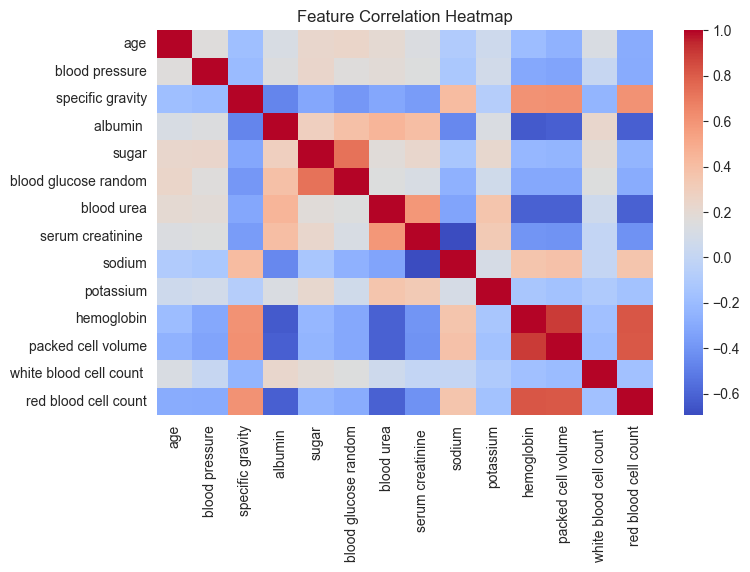

In [11]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()

sns.heatmap(corr, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

df.groupby('classification')[numeric_df.columns].mean()

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,serum creatinine,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count
classification,,,,,,,,,,,,,,
ckd,54.546256,79.517544,1.014031,1.71066,0.810256,177.457286,73.319283,4.537723,133.833333,4.904430,10.600515,32.729885,9127.972028,3.905000
notckd,46.516779,71.351351,1.022414,0.00000,0.000000,107.722222,32.798611,0.868966,141.731034,4.337931,15.188194,46.335616,7705.594406,5.379021
